# ***Regiones admisibles del proceso ARMA(1,1)***

**Considere un proceso ARMA(1,1):**

$$
(1 - \phi B) W_t = (1 - \theta B) \alpha_t \quad ; \quad \alpha_t \sim \text{wn}(0, \sigma_{\alpha}^2)
$$

**A partir de las condiciones para estacionariedad e invertibilidad**:  
$|\phi| < 1$ y $|\theta| < 1$, se tienen las siguientes **regiones admisibles**:

---


In [5]:
import plotly.io as pio
pio.renderers.default = "png"
from pizarras.plotly_pages import PlotlyPagesPublisher
publisher = PlotlyPagesPublisher(
    github_username="nuriaarroyo",
    github_repo="ecoII",
    pages_root="docs",
)

In [6]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ========= util: stem azul + bolitas rojas =========
def stem_blue_red(x, y, name=""):
    xs, ys = [], []
    for xi, yi in zip(x, y):
        xs += [xi, xi, None]
        ys += [0, yi, None]

    stems = go.Scatter(
        x=xs, y=ys,
        mode="lines",
        line=dict(color="blue", width=2),
        showlegend=False,
        name=name
    )
    dots = go.Scatter(
        x=x, y=y,
        mode="markers",
        marker=dict(size=7, color="red"),
        showlegend=False,
        name=name,
        hovertemplate="k=%{x}<br>valor=%{y:.4f}<extra></extra>"
    )
    return stems, dots


# ========= FAC teórica ARMA(1,1) =========
# Convención: (1 - φB) X_t = (1 - θB) Z_t
# => X_t = [(1 - θB)/(1 - φB)] Z_t
# psi_0=1, psi_j = φ^(j-1) (φ - θ) para j>=1
def acf_arma11(phi, theta, m):
    lags = np.arange(m + 1)
    rho = np.zeros(m + 1, dtype=float)
    rho[0] = 1.0

    # si |phi|>=1 la ACF "teórica" de estacionariedad no aplica bien,
    # pero igual devolvemos fórmula (te servirá para ver qué pasa).
    denom0 = 1.0 + (phi - theta) ** 2 / (1.0 - phi ** 2)  # gamma0 / sigma^2

    for k in range(1, m + 1):
        # gamma_k / sigma^2
        gamk = (phi ** (k - 1)) * (phi - theta) + ((phi - theta) ** 2) * (phi ** k) / (1.0 - phi ** 2)
        rho[k] = gamk / denom0

    return lags, rho


# ========= PACF desde ACF (Durbin–Levinson) =========
def pacf_from_acf(rho, m):
    pacf = np.zeros(m + 1, dtype=float)
    pacf[0] = 1.0
    if m == 0:
        return pacf

    phi = np.zeros((m + 1, m + 1), dtype=float)
    v   = np.zeros(m + 1, dtype=float)

    phi[1, 1] = rho[1]
    pacf[1]   = rho[1]
    v[1]      = 1.0 - rho[1] ** 2

    for k in range(2, m + 1):
        num = rho[k] - sum(phi[k - 1, j] * rho[k - j] for j in range(1, k))
        den = v[k - 1]
        phi[k, k] = num / den

        for j in range(1, k):
            phi[k, j] = phi[k - 1, j] - phi[k, k] * phi[k - 1, k - j]

        v[k] = v[k - 1] * (1.0 - phi[k, k] ** 2)
        pacf[k] = phi[k, k]

    return pacf


def panel_arma11(phi=0.5, theta=0.2, m=20, show_diag=True):
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Modelo / región admisible", "FAC (ρ_k) teórica", "FACP (φ_k) teórica"),
        column_widths=[0.42, 0.29, 0.29],
        horizontal_spacing=0.08
    )

    # ===== 1) Región admisible (cuadrado |phi|<1, |theta|<1) =====
    # rectángulo verde (cuadrado)
    fig.add_shape(
        type="rect",
        x0=-1, x1=1, y0=-1, y1=1,
        xref="x1", yref="y1",
        fillcolor="lightgreen",
        opacity=0.35,
        line_width=0,
        layer="below"
    )

    # ejes
    fig.add_trace(go.Scatter(x=[-1.2, 1.2], y=[0, 0], mode="lines",
                             line=dict(color="gray", width=2), showlegend=False),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=[0, 0], y=[-1.2, 1.2], mode="lines",
                             line=dict(color="gray", width=2), showlegend=False),
                  row=1, col=1)

    # diagonal theta = phi (como en tu imagen)
    if show_diag:
        fig.add_trace(go.Scatter(x=[-1.2, 1.2], y=[-1.2, 1.2], mode="lines",
                                 line=dict(color="gray", width=1, dash="dot"),
                                 showlegend=False),
                      row=1, col=1)

    # punto (phi, theta)
    fig.add_trace(go.Scatter(
        x=[phi], y=[theta],
        mode="markers",
        marker=dict(size=12, color="black"),
        showlegend=False,
        hovertemplate="φ=%{x:.2f}<br>θ=%{y:.2f}<extra></extra>"
    ), row=1, col=1)

    fig.add_annotation(
        x=phi, y=theta, xref="x1", yref="y1",
        text=f"({phi:.2f}, {theta:.2f})",
        showarrow=True, arrowhead=2, ax=25, ay=-25
    )

    fig.update_xaxes(range=[-1.2, 1.2], title_text="φ", row=1, col=1)
    fig.update_yaxes(range=[-1.2, 1.2], title_text="θ", row=1, col=1)

    # ===== 2) FAC =====
    lags, rho = acf_arma11(phi, theta, m)
    stems, dots = stem_blue_red(lags, rho)
    fig.add_trace(stems, row=1, col=2)
    fig.add_trace(dots,  row=1, col=2)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=2)
    fig.update_xaxes(title_text="k", row=1, col=2)
    fig.update_yaxes(range=[-1, 1], title_text="ρ_k", row=1, col=2)

    # ===== 3) FACP =====
    pacf = pacf_from_acf(rho, m)
    lags_p = np.arange(m + 1)
    stems, dots = stem_blue_red(lags_p, pacf)
    fig.add_trace(stems, row=1, col=3)
    fig.add_trace(dots,  row=1, col=3)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=3)
    fig.update_xaxes(title_text="k", row=1, col=3)
    fig.update_yaxes(range=[-1, 1], title_text="φ_k (PACF)", row=1, col=3)

    # título general + check región
    ok = (abs(phi) < 1) and (abs(theta) < 1)
    chk = "✓" if ok else "✗"

    fig.update_layout(
        template="plotly_white",
        width=1250,
        height=360,
        margin=dict(l=40, r=20, t=80, b=45),
        title=dict(
            text=f"ARMA(1,1): (1 - φB)X_t = (1 - θB)Z_t —" 
            f"punto {chk} en la región (|φ|<1, |θ|<1)"
            f"<br>φ={phi}, θ={theta}",
            x=0.5, xanchor="center"
        ),
        showlegend=False
    )
    return fig



In [7]:
def arma11_region_number(phi, theta):
    if not (-1 < phi < 1 and -1 < theta < 1):
        return None  # fuera de la región admisible

    if phi < 0 and theta > 0:
        return 1

    if phi > 0 and theta > 0:
        return 2 if theta > phi else 3

    if phi < 0 and theta < 0:
        return 4 if theta > phi else 5

    if phi > 0 and theta < 0:
        return 6

import plotly.graph_objects as go

def arma11_region_quad(phi_point=0.4, theta_point=0.2):
    region = arma11_region_number(phi_point, theta_point)

    fig = go.Figure()

    # --- cuadrado admisible ---
    fig.add_trace(go.Scatter(
        x=[-1, 1, 1, -1, -1],
        y=[-1, -1, 1, 1, -1],
        mode="lines",
        line=dict(color="black", width=1),
        fill="toself",
        fillcolor="rgba(144,238,144,0.4)",
        showlegend=False
    ))

    # --- ejes ---
    fig.add_trace(go.Scatter(x=[-1.2, 1.2], y=[0, 0],
                             mode="lines", line=dict(color="gray", width=2),
                             showlegend=False))
    fig.add_trace(go.Scatter(x=[0, 0], y=[-1.2, 1.2],
                             mode="lines", line=dict(color="gray", width=2),
                             showlegend=False))

    # --- diagonal θ = φ ---
    fig.add_trace(go.Scatter(
        x=[-1.2, 1.2], y=[-1.2, 1.2],
        mode="lines",
        line=dict(color="black", dash="dot"),
        showlegend=False
    ))

    # --- punto ---
    fig.add_trace(go.Scatter(
        x=[phi_point], y=[theta_point],
        mode="markers+text",
        marker=dict(size=12, color="red"),
        text=[f"({phi_point:.2f},{theta_point:.2f})"],
        textposition="bottom center",
        showlegend=False
    ))

    # --- etiquetas de regiones ---
    fig.add_annotation(x=-0.6, y= 0.6, text="R1", showarrow=False)
    fig.add_annotation(x= 0.6, y= 0.6, text="R2 / R3", showarrow=False)
    fig.add_annotation(x=-0.6, y=-0.6, text="R4 / R5", showarrow=False)
    fig.add_annotation(x= 0.6, y=-0.6, text="R6", showarrow=False)

    fig.update_layout(
        template="simple_white",
        width=700, height=520,
        title=(
            f"ARMA(1,1)<br>"
            f"Región admisible #{region}"
            if region is not None else
            "ARMA(1,1) — punto fuera de la región admisible"
        ),
        xaxis=dict(title="φ", range=[-1.2, 1.2]),
        yaxis=dict(title="θ", range=[-1.2, 1.2]),
        showlegend=False
    )

    return fig



**Región admisible 1:**  
$-1 < \phi < 0$ y $0 < \theta < 1$


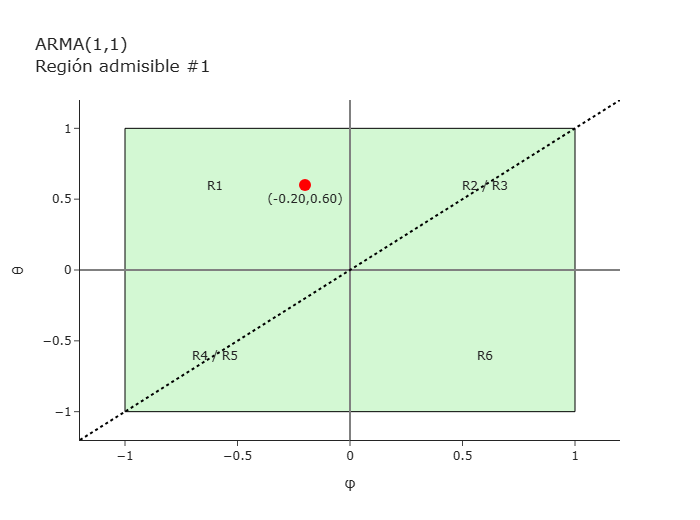

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_br_Regi%C3%B3n_admisible_1.html


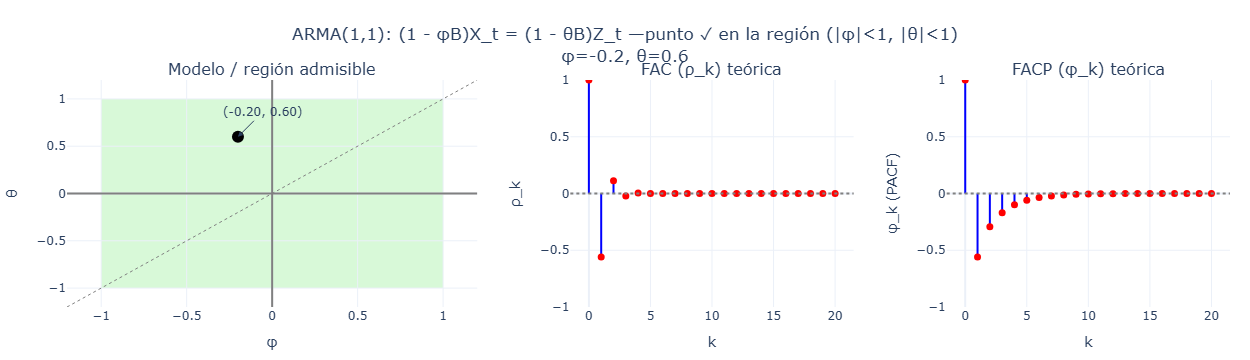

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_1_-_%CF%86B_X_t_1_-_%CE%B8B_Z_t_punto_en_la_regi%C3%B3n_%CF%86_1_%CE%B8_1_br_%CF%86_-0_2_%CE%B8_0_6.html


In [8]:
phi= -0.2 
theta = 0.6
fig = arma11_region_quad(phi_point=phi, theta_point=theta)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)
fig = panel_arma11(phi=phi, theta=theta, m=20, show_diag=True)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)


**FAC teórica:**

$$
\rho_k = \frac{\phi^{k-1} (1 - \theta)(\phi - \theta)}{1 - 2\phi\theta + \theta^2}, \quad k = 1, 2, \dots
$$
---

**Región admisible 2:**

$$
0 < \phi < 1 \quad ; \quad 0 < \theta < 1 \quad ; \quad \theta > \phi
$$


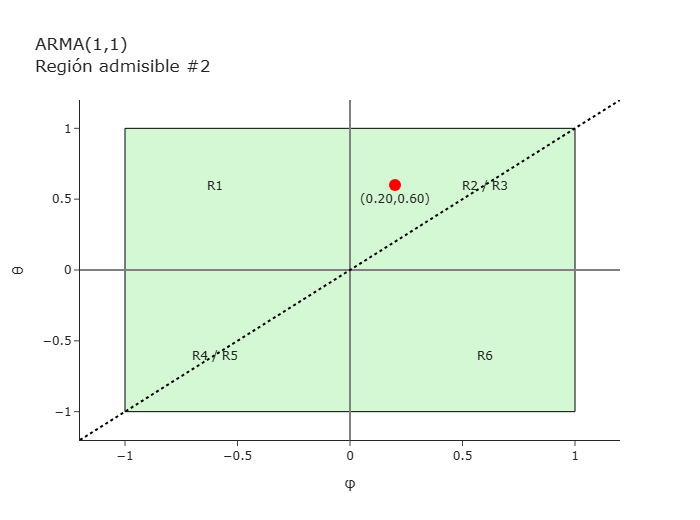

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_br_Regi%C3%B3n_admisible_2.html


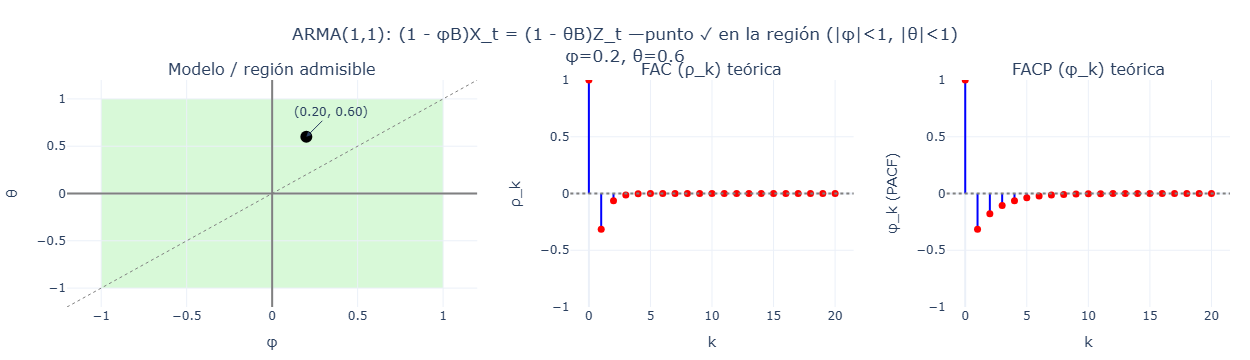

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_1_-_%CF%86B_X_t_1_-_%CE%B8B_Z_t_punto_en_la_regi%C3%B3n_%CF%86_1_%CE%B8_1_br_%CF%86_0_2_%CE%B8_0_6.html


In [9]:
phi= 0.2 
theta = 0.6
fig = arma11_region_quad(phi_point=phi, theta_point=theta)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)
fig = panel_arma11(phi=phi, theta=theta, m=20, show_diag=True)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)


---

**Región admisible 3:**

$$
0 < \phi < 1 \quad ; \quad 0 < \theta < 1 \quad ; \quad \theta < \phi
$$



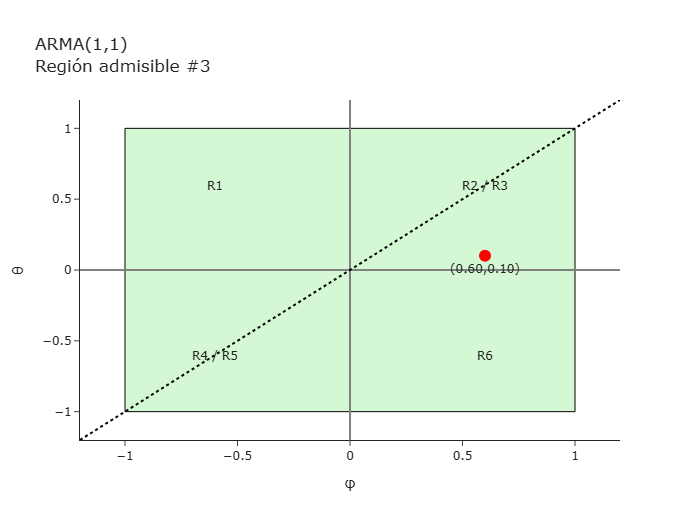

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_br_Regi%C3%B3n_admisible_3.html


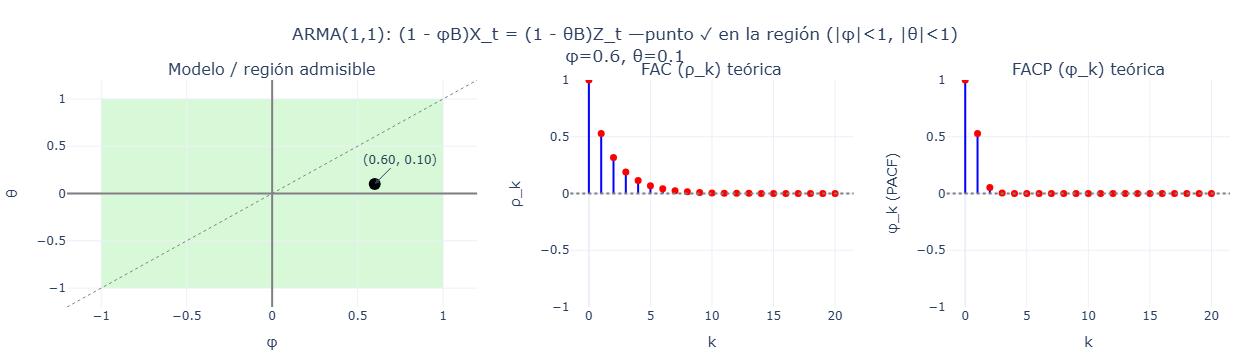

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_1_-_%CF%86B_X_t_1_-_%CE%B8B_Z_t_punto_en_la_regi%C3%B3n_%CF%86_1_%CE%B8_1_br_%CF%86_0_6_%CE%B8_0_1.html


In [10]:
phi= 0.6 
theta = 0.1
fig = arma11_region_quad(phi_point=phi, theta_point=theta)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)
fig = panel_arma11(phi=phi, theta=theta, m=20, show_diag=True)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)



---

**Región admisible 4:**

$$
-1 < \phi < 0 \quad ; \quad -1 < \theta < 0 \quad ; \quad \theta > \phi
$$


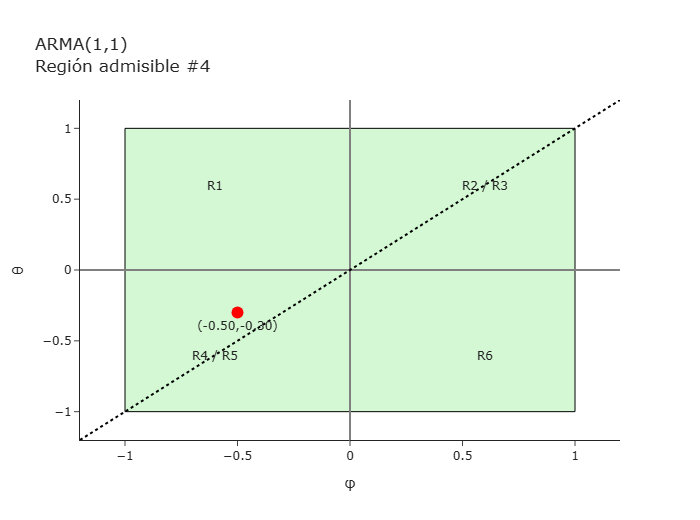

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_br_Regi%C3%B3n_admisible_4.html


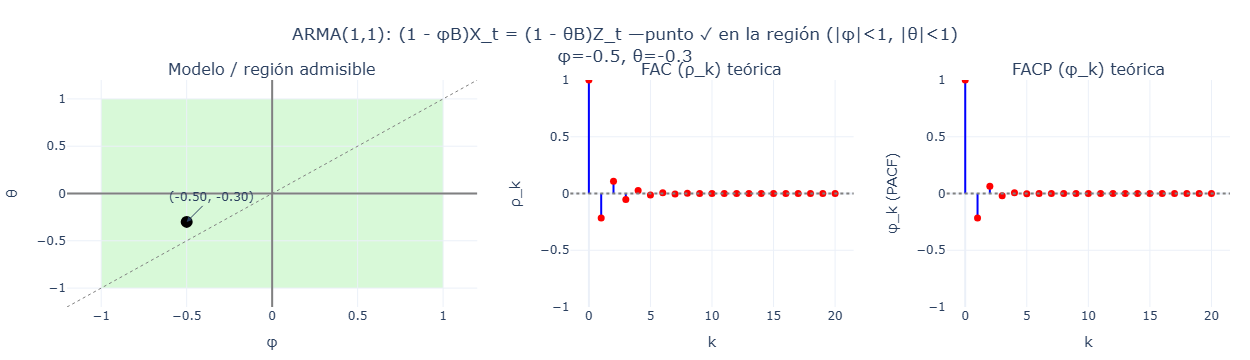

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_1_-_%CF%86B_X_t_1_-_%CE%B8B_Z_t_punto_en_la_regi%C3%B3n_%CF%86_1_%CE%B8_1_br_%CF%86_-0_5_%CE%B8_-0_3.html


In [11]:
phi= -0.5
theta = -0.3
fig = arma11_region_quad(phi_point=phi, theta_point=theta)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)
fig = panel_arma11(phi=phi, theta=theta, m=20, show_diag=True)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)


---

**Región admisible 5:**

$$
-1 < \phi < 0 \quad ; \quad -1 < \theta < 0 \quad ; \quad \theta < \phi
$$


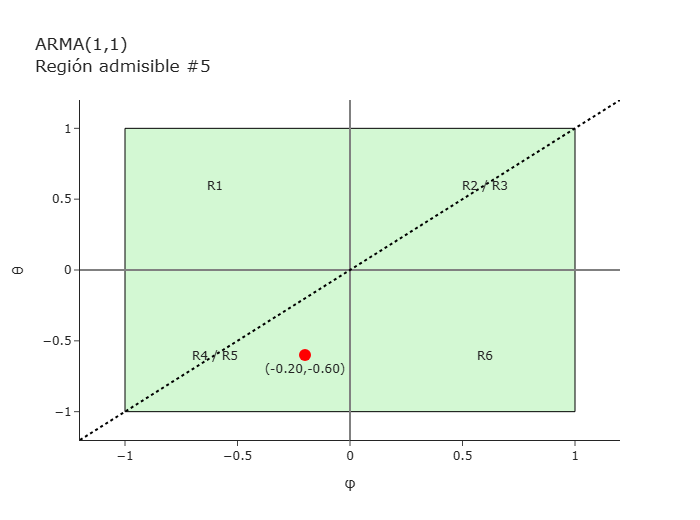

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_br_Regi%C3%B3n_admisible_5.html


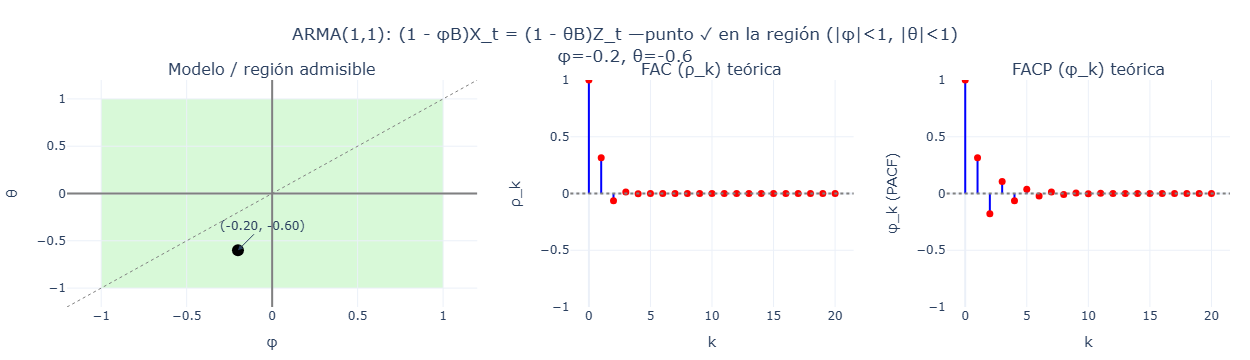

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_1_-_%CF%86B_X_t_1_-_%CE%B8B_Z_t_punto_en_la_regi%C3%B3n_%CF%86_1_%CE%B8_1_br_%CF%86_-0_2_%CE%B8_-0_6.html


In [12]:
phi= -0.2 
theta = -0.6
fig = arma11_region_quad(phi_point=phi, theta_point=theta)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)
fig = panel_arma11(phi=phi, theta=theta, m=20, show_diag=True)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)


---

**Región admisible 6:**

$$
0 < \phi < 1 \quad ; \quad -1 < \theta < 0
$$


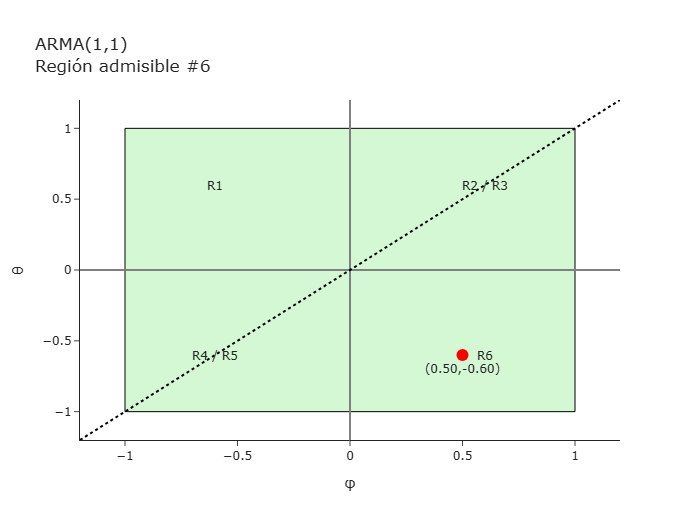

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_br_Regi%C3%B3n_admisible_6.html


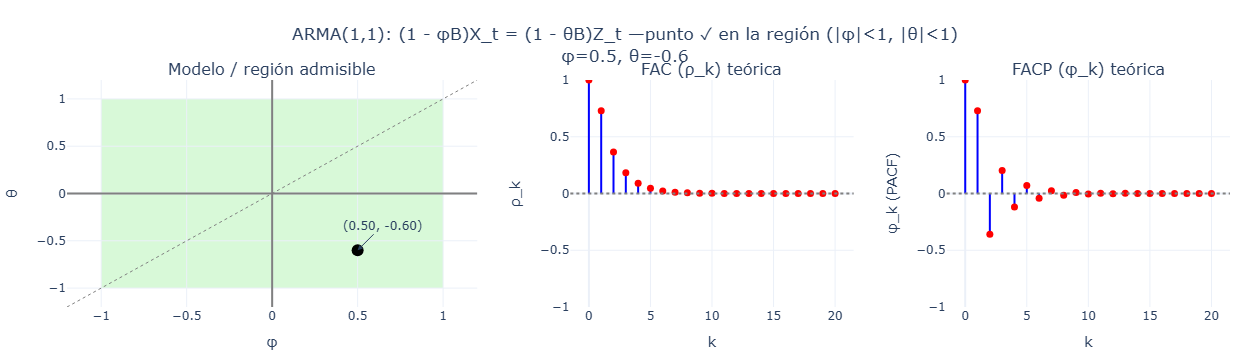

https://nuriaarroyo.github.io/ecoII/interactive/ARMA_1_1_1_-_%CF%86B_X_t_1_-_%CE%B8B_Z_t_punto_en_la_regi%C3%B3n_%CF%86_1_%CE%B8_1_br_%CF%86_0_5_%CE%B8_-0_6.html


In [13]:
phi= 0.5 
theta = -0.6
fig = arma11_region_quad(phi_point=phi, theta_point=theta)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)
fig = panel_arma11(phi=phi, theta=theta, m=20, show_diag=True)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)
print(pdf_url)